In [1]:
import re
import os
import sys
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet, stopwords
from nltk import pos_tag
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOP_WORDS

import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

try:
    from sklearn.cluster import HDBSCAN
except Exception:
    HDBSCAN = None


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)

    for p in [start.resolve()] + list(start.resolve().parents):
        if (p / "csvs").exists() and (p / "markdown").exists():
            return p

    return start.resolve()


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    import scripts.text_mining_utils as tmu
except Exception:
    tmu = None


CSVS_CHUNKED = PROJECT_ROOT / "csvs" / "chunked"
CHUNKS_ALL = CSVS_CHUNKED / "chunks_all.csv"

PIPELINE_DIR = PROJECT_ROOT / "progress" / "topic_modelling" / "lda" / "policy"

OUT_DIR = PIPELINE_DIR / "output"
IMG_DIR = PIPELINE_DIR / "img"

OUT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

NLTK_DATA_DIR = PROJECT_ROOT / "data" / "auto"
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)
nltk.data.path.append(str(NLTK_DATA_DIR))

nltk_packages = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
]

for package in nltk_packages:
    try:
        nltk.download(package, download_dir=str(NLTK_DATA_DIR), quiet=True)
    except Exception as e:
        print(f"Warning: NLTK package not available: {package} ({e})")

print("Project root:", PROJECT_ROOT)
print("Input chunks file:", CHUNKS_ALL)
print("Pipeline folder:", PIPELINE_DIR)
print("Output folder:", OUT_DIR)
print("Utility module:", None if tmu is None else tmu.__name__)

Project root: /home/nsirim/Github/mscdsa/msc
Input chunks file: /home/nsirim/Github/mscdsa/msc/csvs/chunked/chunks_all.csv
Pipeline folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/policy
Output folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/policy/output
Utility module: scripts.text_mining_utils


In [2]:
# ==========================================
# Step 1: Loading data and preliminary cleaning
# ==========================================

CORPUS_FILTER = "policy"

required_columns = {
    "doc_id",
    "corpus",
    "source_type",
    "country",
    "heading_context",
    "chunk_text",
}


def safe_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def normalise_heading_text(heading):
    heading = safe_text(heading)
    heading = re.sub(r"\s+", " ", heading)
    heading = re.sub(r"^\d+(\.\d+)*\s+", "", heading)
    return heading.strip()


def build_original_heading_context_chunk_text(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_text = safe_text(row["chunk_text"])

    if heading and chunk_text.lower().startswith(heading.lower()):
        return chunk_text

    return f"{heading} {chunk_text}".strip()


def build_lda_source_text(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_text = safe_text(row["chunk_text"])

    if not heading:
        return chunk_text

    if chunk_text.lower().startswith(heading.lower()):
        return chunk_text

    heading_word_count = len(heading.split())

    if heading_word_count <= 12:
        return f"{heading}. {chunk_text}"

    return chunk_text


def remove_document_artifact_chunks(dataframe):
    artifact_heading_pattern = re.compile(
        r"^(contents|table of contents|acknowledgements?|acknowledgments?|"
        r"acronyms?|abbreviations?|illustrations?|bibliography|references|"
        r"web sources|about the author|about the authors|authors?|cover|"
        r"copyright|appendix|annex|figures?|tables?|foreword|preface)$",
        re.IGNORECASE
    )

    artifact_text_pattern = re.compile(
        r"(table of contents|copyright|all rights reserved|isbn|bibliography|"
        r"references|web sources|cover photo|printed in|printed by|"
        r"designed and printed|directorate of communications|creative commons|"
        r"open access repository|legal status of any country|frontiers or boundaries|"
        r"does not imply the expression|shutterstock|doi\.org|creativecommons|"
        r"attribution-sharealike)",
        re.IGNORECASE
    )

    heading_mask = (
        dataframe["heading_context"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.match(artifact_heading_pattern)
    )

    text_mask = (
        dataframe["chunk_text"]
        .fillna("")
        .astype(str)
        .str[:900]
        .str.contains(artifact_text_pattern, regex=True, na=False)
    )

    artifact_mask = heading_mask | text_mask

    return dataframe.loc[~artifact_mask].copy(), int(artifact_mask.sum())


try:
    print("Input file:", CHUNKS_ALL)

    df = pd.read_csv(CHUNKS_ALL, encoding="utf-8-sig")

    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    df = df[df["corpus"] == CORPUS_FILTER].copy()

    UNESCO_DOC_IDS = {
        "policy_ai_competency_framework_for_students",
        "policy_ai_competency_framework_for_teachers",
    }

    unesco_mask = df["doc_id"].isin(UNESCO_DOC_IDS)
    df.loc[unesco_mask, "country"] = "unesco"

    df["heading_context"] = df["heading_context"].fillna("").astype(str)
    df["chunk_text"] = df["chunk_text"].fillna("").astype(str)

    df = df[df["chunk_text"] != "N/A"].copy()
    df = df[df["chunk_text"].str.strip() != ""].copy()

    df, removed_artifact_chunks = remove_document_artifact_chunks(df)

    df["heading_context_chunk_text"] = df.apply(
        build_original_heading_context_chunk_text,
        axis=1
    )

    df["lda_source_text"] = df.apply(
        build_lda_source_text,
        axis=1
    )

    df = df[df["lda_source_text"].str.len() > 0].copy()

    print(f"Loaded policy chunks: {len(df)}")
    print(f"Removed document-artifact chunks: {removed_artifact_chunks}")
    print(f"Countries: {df['country'].nunique()} including UNESCO International documents")
    print("\nChunks by country:")
    print(df["country"].value_counts(dropna=False))

except FileNotFoundError:
    print("Error: chunks_all.csv not found.")
    print("Expected path:", CHUNKS_ALL)
    raise

except Exception as e:
    print(f"Error while loading chunks: {e}")
    raise

Input file: /home/nsirim/Github/mscdsa/msc/csvs/chunked/chunks_all.csv
Loaded policy chunks: 1843
Removed document-artifact chunks: 209
Countries: 5 including UNESCO International documents

Chunks by country:
country
usa          539
ireland      435
australia    353
france       312
unesco       204
Name: count, dtype: int64


In [3]:
# ==========================================
# Step 2: Corpus diagnostics before preprocessing
# ==========================================

diagnostic_rows = []

for country, country_df in df.groupby("country"):
    diagnostic_rows.append({
        "country": country,
        "documents": country_df["doc_id"].nunique(),
        "chunks": len(country_df),
        "mean_chunk_words": country_df["chunk_word_count"].mean()
        if "chunk_word_count" in country_df.columns else np.nan,
        "median_chunk_words": country_df["chunk_word_count"].median()
        if "chunk_word_count" in country_df.columns else np.nan,
        "min_chunk_words": country_df["chunk_word_count"].min()
        if "chunk_word_count" in country_df.columns else np.nan,
        "max_chunk_words": country_df["chunk_word_count"].max()
        if "chunk_word_count" in country_df.columns else np.nan,
    })

diagnostics_df = pd.DataFrame(diagnostic_rows).sort_values("country")

print("Corpus diagnostics:")
print(diagnostics_df.to_string(index=False))

diagnostics_path = OUT_DIR / "corpus_diagnostics_before_preprocessing.csv"
diagnostics_df.to_csv(diagnostics_path, index=False, encoding="utf-8-sig")

print(f"\nSaved: {diagnostics_path}")

print("\nPotential weakness to check:")
print("- Countries are not equally represented.")
print("- Some chunks may be too short to produce coherent topics.")
print("- Repeated headings may artificially influence topics.")
print("- Global LDA may be dominated by countries with more chunks.")

Corpus diagnostics:
  country  documents  chunks  mean_chunk_words  median_chunk_words  min_chunk_words  max_chunk_words
australia         17     353        230.237960               216.0               41              651
   france          7     312        257.089744               272.5                8              701
  ireland         15     435        260.618391               298.0                7              554
   unesco          2     204        267.068627               314.5               80              437
      usa         15     539        236.170686               218.0                8             1500

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/policy/output/corpus_diagnostics_before_preprocessing.csv

Potential weakness to check:
- Countries are not equally represented.
- Some chunks may be too short to produce coherent topics.
- Repeated headings may artificially influence topics.
- Global LDA may be dominated by countries with more chunks.


In [4]:
# ==========================================
# Step 3: Stopwords definition and loading
# ==========================================

stop_words = set(SPACY_STOP_WORDS)
stop_words.update(set(stopwords.words("english")))

try:
    stop_words.update(set(stopwords.words("french")))
except Exception:
    print("Warning: French stopwords not found.")

document_artifact_stopwords = [
    "pdf", "qxp", "page", "copyright", "reserved",
    "www", "http", "https", "com", "org",
    "figure", "table", "annex", "appendix", "footnote", "endnote",
    "isbn", "bibliography", "citation", "reference", "metadata", "docx",
    "executive summary", "draft", "matrix", "blueprint", "snapshot",
    "chart", "brochure", "fig"
]

legal_structure_stopwords = [
    "section", "chapter", "part", "title", "article", "clause",
    "paragraph", "subparagraph", "schedule", "exhibit", "supplement",
    "addendum", "preamble", "recital", "report",
    "chapitre", "partie", "titre", "paragraphe", "alinea",
    "annexe", "appendice", "expos", "des", "motifs",
    "disposition"
]

legal_boilerplate_stopwords = [
    "coppa", "ferpa", "enact", "bit",
    "herein", "therein", "thereof", "whereof", "hereby",
    "whereby", "hereinafter", "thereafter", "aforementioned",
    "foregoing", "henceforth", "whereto", "whereupon",
    "notwithstanding", "pursuant", "thereto", "thereunder", "hereto",
    "susmentionn", "prcit", "nonobstant", "par drogation",
    "en", "consquence", "eu", "gard", "aux fins",
    "selon", "conformment", "outre", "ladite", "ledit", "dune"
]

policy_action_stopwords = [
    "shall", "must", "may", "might", "could", "would", "should", "will",
    "require", "requires", "required",
    "ensure", "ensures",
    "seek", "seeks", "seeking",
    "establish", "establishes",
    "promote", "promotes", "promoting",
    "maintain", "respect",
    "doit", "devrait", "pourrait", "vouloir",
    "exiger", "requis", "assurer", "garantir",
    "rechercher", "tablir", "promouvoir",
    "maintenir", "respecter"
]

policy_connector_stopwords = [
    "various", "several", "multiple", "certain", "relevant", "appropriate",
    "regarding", "concerning", "involving", "accordance",
    "relate", "relates", "relating",
    "furthermore", "moreover", "therefore", "thus", "hence",
    "however", "although", "including", "etc", "etcetera",
    "concernant", "divers", "plusieurs", "particulier",
    "certain", "aussi", "de plus", "en outre",
    "par consquent", "donc", "ainsi", "cependant",
    "bien que", "notamment", "entre autres", "comme",
    "toute", "tous", "cette", "plus", "leurs"
]

geo_institutional_stopwords = [
    "ireland", "irish", "france", "french", "usa", "america",
    "australia", "australian",
    "country", "nation", "national", "state",
    "government", "federal", "ministry", "department",
    "gouvernement", "ministre", "dtat", "republic",
    "pittsburg", "antioch", "medina", "winterset",
    "sara", "washington", "california", "massachusetts",
    "oregon", "sweden", "unified", "district",
    "commonwealth", "nsw"
]

tech_ai_stopwords = [
    "artificial", "intelligence",
    "ai", "ia", "lia", "dia",
    "genai", "generative",
    "model", "models", "llm",
    "algorithm", "algorithms",
    "machine", "learning",
    "data", "dataset", "datasets",
    "digital", "numrique",
    "computer", "software", "hardware",
    "technology", "technological",
    "platform", "online", "internet", "web", "electronic",
    "tool", "system", "device", "application", "app", "service",
    "broadband", "connectivity", "vendor", "player", "enterprise",
    "artificielle", "gen", "generatif",
    "modle", "modles",
    "apprentissage", "donn",
    "ordinateur", "logiciel", "matriel",
    "technologie", "plateforme", "ligne",
    "ectronique", "outil", "systme", "dispositif",
    "générative", "intelligent",
    "edge", "gpt", "openai", "microsoft", "google",
    "amazon", "meta", "ibm", "nvidia", "intel",
    "gemini", "deepseek", "anthropic", "claude",
    "embedding", "transformer", "natural language",
    "climate change", "ieee", "architecture",
    "chatgtp", "copilot", "kwyk", "technologies",
    "new", "work", "law", "system", "systems", "right",
    "services", "based", "case", "support", "human",
    "generated", "related"
]

education_stopwords = [
    "school", "education", "educational",
    "pupil", "classroom", "learning",
    "teacher", "teachers", "schools",
    "student", "students",
    "post", "primary", "technical",
    "cole", "educatif", "enseignant", "enseignats", "enseignants",
    "professeur", "programme",
    "apprentissage", "enseignement", "formation",
    "établissement", "éducation", "école",
    "élève", "élèves",
    "covid", "showcase", "deliverable"
]

org_name_stopwords = [
    "adam", "mary", "jensen", "abraham", "lincoln",
    "knight", "kim", "guez",
    "oecd", "cbs", "webwise", "cosn", "dlf",
    "scoilnet", "deap", "dne", "men",
    "parliament", "commissioner", "public sector",
    "cipa", "protection act", "oide", "tie", "cpd"
]

generic_noise_stopwords = [
    "feel", "like", "everybody", "actually",
    "kid", "employee", "min", "box", "loop",
    "black", "asset", "typical", "era",
    "acquire", "behavioral", "behavioural",
    "revolution", "emission", "talent",
    "billion", "count", "witness", "operator",
    "interim", "resourced", "resourcing",
    "round", "support work", "dashboard",
    "ela", "estonia", "pisa", "perspectives",
    "final", "total", "describe", "visit",
    "original", "sample", "low",
    "answer", "ask", "efficacy",
    "deepen", "enhance",
    "author", "researcher", "mission", "personnel",
    "palo", "alto", "card",
    "use", "lot", "enable", "constituent",
    "session", "policy", "document",
    "member", "organisation", "goal",
    "long term", "desirable", "young",
    "ite", "aied", "australasian",
    "perplexed", "guidetoaiinschools", "nenufsd",
    "dent", "fee", "want", "prof", "stu"
]

date_time_stopwords = [
    "july", "april", "august"
]

policy_corpus_checked_stopwords = [
    "create", "level", "plan", "text", "lesson", "area",
    "assist", "example", "resource", "replace", "available",
    "important", "engage", "provide", "include", "develop",
    "development", "support", "need", "make", "work",
    "way", "role", "view", "approach", "activity",
    "consider", "consideration", "identify", "understand",
    "understanding", "information", "implementation", "implement",
    "process", "practice", "practices", "challenge", "challenges",
    "opportunity", "opportunities", "benefit", "benefits",
    "impact", "impacts", "discussion", "debate", "change",
    "future", "key", "range", "effective", "effectively",
    "access", "issue", "issues", "specific", "general",
    "different", "possible", "stakeholder", "stakeholders",
    "initiative", "initiatives", "committee", "commission",
    "advisory", "program", "civil", "carry", "finding", "find"
]

policy_artifact_checked_stopwords = [
    "author", "authors", "printed", "strasbourg", "cedex",
    "shutterstock", "publishing", "cover", "photo",
    "directorate", "communications"
]

post_cleaning_generic_stopwords = [
    "être", "avoir", "faire", "peut",
    "tout", "tous", "toute", "toutes",
    "autre", "autres",
    "encore", "déjà", "non", "sans",
    "dont", "cela", "même", "mme",
    "très", "moins", "plus", "souvent",
    "cas", "type", "manière", "fonction", "partir",
    "exemple", "question", "réponse", "résultat",
    "objectif", "contenu", "texte", "image"
]

fragment_stopwords = [
    "ing", "tion", "ment", "ness", "ly",
    "able", "ive", "ent", "ant",
    "ence", "ance",
    "ali", "gue", "rod", "rodr",
    "educa", "evi", "al", "ons", "onal", "effec", 
    "con", "consulta", "prac"
]

custom_stopword_categories = [
    document_artifact_stopwords,
    legal_structure_stopwords,
    legal_boilerplate_stopwords,
    policy_action_stopwords,
    policy_connector_stopwords,
    geo_institutional_stopwords,
    tech_ai_stopwords,
    education_stopwords,
    org_name_stopwords,
    generic_noise_stopwords,
    date_time_stopwords,
    policy_corpus_checked_stopwords,
    policy_artifact_checked_stopwords,
    post_cleaning_generic_stopwords,
    fragment_stopwords,
]

custom_stopwords = set()

for category in custom_stopword_categories:
    custom_stopwords.update(category)

stop_words.update(custom_stopwords)

print(f"Stopwords loaded: {len(stop_words)}")

Stopwords loaded: 1092


In [5]:
# ==========================================
# Step 4: Cleaning and preprocessing helpers
# ==========================================

lemmatizer = WordNetLemmatizer()

extra_french_stopwords = {
    "la", "le", "les", "de", "un", "une", "des", "du", "au", "aux",
    "ce", "cet", "cette", "ces", "je", "me", "te", "se", "ne",
    "que", "qui", "quoi", "dont", "dans", "pour", "par", "sur",
    "avec", "sans", "plus", "moins", "tres", "très", "pas",
    "tout", "tous", "toute", "toutes", "autre", "autres",
    "cela", "meme", "même", "encore"
}

stop_words.update(extra_french_stopwords)


def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("N"):
        return wordnet.NOUN
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def has_non_ascii(token):
    return any(ord(char) > 127 for char in token)


def clean_text(text):
    text = str(text).lower()

    text = text.replace("’", "'").replace("‘", "'").replace("`", "'")
    text = text.replace("guillemetleft", " ")
    text = text.replace("guillemetright", " ")

    ocr_fixes = {
        r"\blve\b": "élève",
        r"\blves\b": "élèves",
        r"\bducation\b": "éducation",
        r"\b1ducation\b": "éducation",
        r"\bducatif\b": "éducatif",
        r"\bducative\b": "éducative",
        r"\bducatifs\b": "éducatifs",
        r"\bducatives\b": "éducatives",
        r"\btablissement\b": "établissement",
        r"\btablissements\b": "établissements",
        r"\bvaluation\b": "évaluation",
        r"\bvaluer\b": "évaluer",
        r"\btrs\b": "très",
        r"\blment\b": "élément",
        r"\blments\b": "éléments",
    }

    for pattern, replacement in ocr_fixes.items():
        text = re.sub(pattern, replacement, text)

    french_contractions = {
        r"\bl'": "la ",
        r"\bd'": "de ",
        r"\bc'": "ce ",
        r"\bj'": "je ",
        r"\bm'": "me ",
        r"\bt'": "te ",
        r"\bs'": "se ",
        r"\bn'": "ne ",
        r"\bqu'": "que ",
        r"\blorsqu'": "lorsque ",
        r"\bpuisqu'": "puisque ",
        r"\bquoiqu'": "quoique ",
        r"\bjusqu'": "jusque ",
        r"\baujourd'": "aujourd ",
    }

    for pattern, replacement in french_contractions.items():
        text = re.sub(pattern, replacement, text)

    text = re.sub(r"\S*@\S*\s?", " ", text)
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\[\d+\]", " ", text)
    text = re.sub(r"\(\s*see\s+[^\)]+\)", " ", text)
    text = re.sub(r"footnote\s*\d+", " ", text)

    text = re.sub(r"\b\d+[\w-]*\b", " ", text)
    text = re.sub(r"\b(amp|lt|gt|quot|nbsp)\b", " ", text)

    text = re.sub(r"[^a-zàâäéèêëïîôùûüÿçæœ\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    cleaned_tokens = []

    for token in tokens:
        token = token.strip("-")

        if not token:
            continue

        if len(token) <= 2:
            continue

        if re.fullmatch(r"[a-zàâäéèêëïîôùûüÿçæœ]-[a-zàâäéèêëïîôùûüÿçæœ]", token):
            continue

        cleaned_tokens.append(token)

    return cleaned_tokens


def remove_stopwords(tokens):
    filtered_tokens = []

    for token in tokens:
        token = token.strip("_-")

        if not token:
            continue

        parts = token.split("_")

        if len(token) <= 2:
            continue

        if token in stop_words:
            continue

        if all(part in stop_words for part in parts):
            continue

        if any(len(part) <= 2 for part in parts):
            continue

        filtered_tokens.append(token)

    return filtered_tokens


def lemmatize_tokens(tokens):
    if not tokens:
        return []

    pos_tags = pos_tag(tokens)

    lemmatized = []

    for token, pos in pos_tags:
        if "_" in token:
            lemmatized.append(token)
        elif has_non_ascii(token):
            lemmatized.append(token)
        else:
            lemmatized.append(
                lemmatizer.lemmatize(token, get_wordnet_pos(pos))
            )

    return lemmatized


def preprocess_without_phrases(text):
    tokens = clean_text(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    tokens = remove_stopwords(tokens)

    return tokens

def preprocess_text(text):
    """
    Unigram-only preprocessing.

    This keeps the LDA vocabulary consistent:
    - no bigrams
    - no trigrams
    - no underscore tokens
    - only cleaned, stopword-filtered, lemmatised single words
    """
    tokens = clean_text(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    tokens = remove_stopwords(tokens)

    # Safety check: remove any remaining compound-style tokens
    tokens = [
        token
        for token in tokens
        if "_" not in token
    ]

    return tokens


In [6]:
# ==========================================
# Step 5: Apply unigram-only preprocessing
# ==========================================

MIN_PROCESSED_TOKENS = 30

df["heading_context_chunk_text_processed_tokens"] = (
    df["lda_source_text"]
    .apply(preprocess_text)
)

df["heading_context_chunk_text_processed"] = (
    df["heading_context_chunk_text_processed_tokens"]
    .apply(lambda tokens: " ".join(tokens))
)

df["processed_token_count"] = (
    df["heading_context_chunk_text_processed_tokens"]
    .apply(len)
)

before_length_filter = len(df)

df = df[df["processed_token_count"] >= MIN_PROCESSED_TOKENS].copy()

after_length_filter = len(df)

before_dedup = len(df)

df = df.drop_duplicates(
    subset=["country", "heading_context_chunk_text_processed"]
).copy()

after_dedup = len(df)

print(f"Rows before token-length filter: {before_length_filter}")
print(f"Rows after token-length filter: {after_length_filter}")
print(f"Rows removed by exact duplicate filtering: {before_dedup - after_dedup}")
print(f"Final rows after unigram-only preprocessing: {len(df)}")

print("\nProcessed token counts:")
print(df["processed_token_count"].describe())

print("\nRows by country after preprocessing:")
print(df["country"].value_counts(dropna=False))

Rows before token-length filter: 1843
Rows after token-length filter: 1728
Rows removed by exact duplicate filtering: 4
Final rows after unigram-only preprocessing: 1724

Processed token counts:
count    1724.000000
mean       88.603248
std        39.310206
min        30.000000
25%        57.000000
50%        86.000000
75%       114.000000
max       516.000000
Name: processed_token_count, dtype: float64

Rows by country after preprocessing:
country
usa          496
ireland      403
australia    319
france       308
unesco       198
Name: count, dtype: int64


In [7]:
# ==========================================
# Step 6: Create global dictionary and corpus
# ==========================================

texts = df["heading_context_chunk_text_processed_tokens"].tolist()

dictionary = corpora.Dictionary(texts)

dictionary.filter_extremes(
    no_below=10,
    no_above=0.20,
    keep_n=2500
)

doc_term_matrix = [
    dictionary.doc2bow(tokens)
    for tokens in texts
]

valid_bow_mask = [
    len(bow) > 0
    for bow in doc_term_matrix
]

df = df[valid_bow_mask].copy()
texts = df["heading_context_chunk_text_processed_tokens"].tolist()

doc_term_matrix = [
    dictionary.doc2bow(tokens)
    for tokens in texts
]

print(f"Dictionary size: {len(dictionary)}")
print(f"Documents in global corpus: {len(doc_term_matrix)}")
print(f"Average tokens per document: {np.mean([len(t) for t in texts]):.2f}")

print("\nDocuments by country in final global corpus:")
print(df["country"].value_counts(dropna=False))

Dictionary size: 2234
Documents in global corpus: 1724
Average tokens per document: 88.60

Documents by country in final global corpus:
country
usa          496
ireland      403
australia    319
france       308
unesco       198
Name: count, dtype: int64


In [8]:
# ==========================================
# Step 7: Post-preprocessing corpus diagnostics
# ==========================================

token_counts = Counter()

for tokens in texts:
    token_counts.update(tokens)

top_tokens_df = pd.DataFrame(
    token_counts.most_common(100),
    columns=["token", "count"]
)

print("Top 50 tokens after preprocessing:")
print(top_tokens_df.head(50).to_string(index=False))

top_tokens_path = OUT_DIR / "top_tokens_after_preprocessing.csv"
top_tokens_df.to_csv(top_tokens_path, index=False, encoding="utf-8-sig")

print(f"\nSaved: {top_tokens_path}")

country_token_rows = []

for country, country_df in df.groupby("country"):
    country_tokens = [
        token
        for tokens in country_df["heading_context_chunk_text_processed_tokens"]
        for token in tokens
    ]

    country_counter = Counter(country_tokens)

    for token, count in country_counter.most_common(30):
        country_token_rows.append({
            "country": country,
            "token": token,
            "count": count
        })

country_top_tokens_df = pd.DataFrame(country_token_rows)

country_top_tokens_path = OUT_DIR / "top_tokens_by_country_after_preprocessing.csv"
country_top_tokens_df.to_csv(country_top_tokens_path, index=False, encoding="utf-8-sig")

print(f"Saved: {country_top_tokens_path}")

Top 50 tokens after preprocessing:
         token  count
         child   1138
        design    774
         teach    729
    assessment    670
     framework    652
       ethical    633
     principle    603
      research    589
         skill    585
       privacy    556
      strategy    552
      guidance    536
       content    521
          risk    514
        public    509
          help    485
         focus    458
       learner    449
     knowledge    448
    competency    440
         staff    415
      educator    414
      literacy    402
  professional    399
        people    398
      decision    389
    curriculum    386
     potential    384
         usage    384
        social    382
recommendation    369
         guide    368
       address    366
        review    365
           set    345
          task    342
     guideline    336
          bias    334
       context    332
    regulation    331
         group    326
        action    322
     community    3

In [9]:
# ==========================================
# Step 8: LDA helper functions
# ==========================================

def topic_diversity(model, topn=15):
    topic_words = []

    for topic_id in range(model.num_topics):
        topic_words.extend([
            word
            for word, weight in model.show_topic(topic_id, topn=topn)
        ])

    if len(topic_words) == 0:
        return 0

    return len(set(topic_words)) / len(topic_words)


def fit_lda_grid(texts, dictionary, doc_term_matrix, topic_range):
    coherence_scores = []
    diversity_scores = []
    lda_models = []

    for num_topics in topic_range:
        lda_model = LdaModel(
            corpus=doc_term_matrix,
            id2word=dictionary,
            num_topics=num_topics,
            chunksize=1000,
            passes=20,
            iterations=300,
            random_state=43,
            update_every=1,
            alpha="auto",
            eta="auto",
            minimum_probability=0.01,
            eval_every=None
        )

        coherence_model = CoherenceModel(
            model=lda_model,
            texts=texts,
            dictionary=dictionary,
            coherence="c_v",
            topn=10
        )

        coherence = coherence_model.get_coherence()
        diversity = topic_diversity(lda_model, topn=15)

        lda_models.append(lda_model)
        coherence_scores.append(coherence)
        diversity_scores.append(diversity)

        print(
            f"Topics: {num_topics} | "
            f"Coherence: {coherence:.4f} | "
            f"Diversity: {diversity:.4f}"
        )

    return {
        "topic_range": topic_range,
        "coherence_scores": coherence_scores,
        "diversity_scores": diversity_scores,
        "lda_models": lda_models
    }


def select_best_model(grid_result, min_diversity=0.80):
    coherence_scores = grid_result["coherence_scores"]
    diversity_scores = grid_result["diversity_scores"]

    valid_indices = [
        i
        for i, diversity in enumerate(diversity_scores)
        if diversity >= min_diversity
    ]

    if len(valid_indices) > 0:
        best_idx = max(
            valid_indices,
            key=lambda i: coherence_scores[i]
        )
    else:
        best_idx = int(np.argmax(coherence_scores))

    return best_idx

In [10]:
# ==========================================
# Step 9: Determine global optimal topics
# ==========================================

topic_range = [3, 4, 5, 6, 7, 8, 9, 10]

print("Running global LDA grid search...")

global_grid = fit_lda_grid(
    texts=texts,
    dictionary=dictionary,
    doc_term_matrix=doc_term_matrix,
    topic_range=topic_range
)

best_idx = select_best_model(global_grid, min_diversity=0.80)

best_num_topics = topic_range[best_idx]
best_coherence = global_grid["coherence_scores"][best_idx]
best_diversity = global_grid["diversity_scores"][best_idx]
best_lda_model = global_grid["lda_models"][best_idx]

print("\nBest global model:")
print(f"Best number of topics: {best_num_topics}")
print(f"Best coherence score: {best_coherence:.4f}")
print(f"Best topic diversity: {best_diversity:.4f}")

Running global LDA grid search...
Topics: 3 | Coherence: 0.6300 | Diversity: 0.9333
Topics: 4 | Coherence: 0.7021 | Diversity: 0.9000
Topics: 5 | Coherence: 0.6576 | Diversity: 0.8800
Topics: 6 | Coherence: 0.6297 | Diversity: 0.8667
Topics: 7 | Coherence: 0.6424 | Diversity: 0.8952
Topics: 8 | Coherence: 0.6700 | Diversity: 0.8000
Topics: 9 | Coherence: 0.5829 | Diversity: 0.8593
Topics: 10 | Coherence: 0.6267 | Diversity: 0.8267

Best global model:
Best number of topics: 4
Best coherence score: 0.7021
Best topic diversity: 0.9000


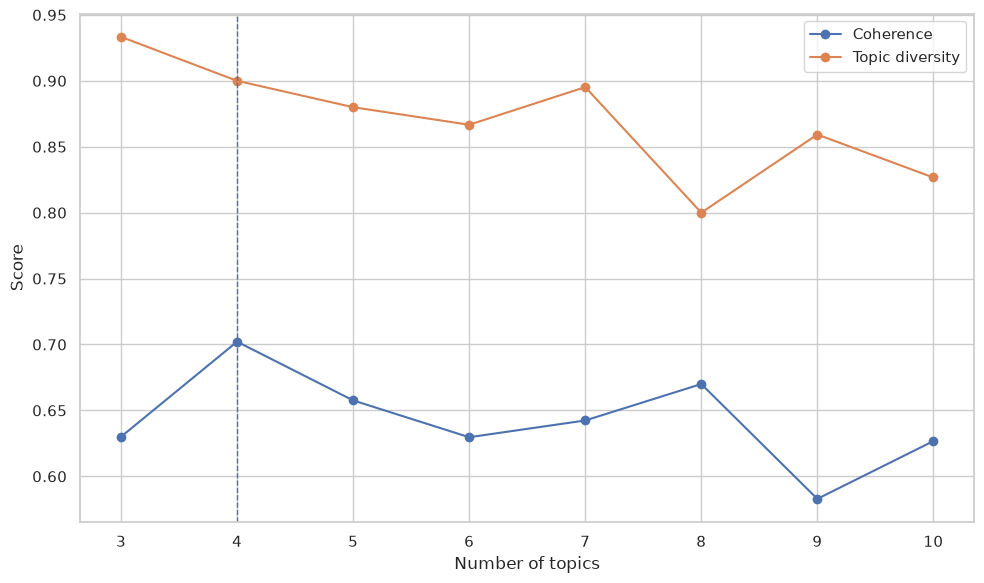

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/policy/img/lda_global_coherence_diversity.png


In [11]:
# ==========================================
# Plot global coherence and diversity scores
# ==========================================

global_scores_df = pd.DataFrame({
    "num_topics": topic_range,
    "coherence_score": global_grid["coherence_scores"],
    "topic_diversity": global_grid["diversity_scores"]
})

plt.figure(figsize=(10, 6))

plt.plot(
    global_scores_df["num_topics"],
    global_scores_df["coherence_score"],
    marker="o",
    label="Coherence"
)

plt.plot(
    global_scores_df["num_topics"],
    global_scores_df["topic_diversity"],
    marker="o",
    label="Topic diversity"
)

plt.axvline(
    best_num_topics,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Number of topics")
plt.ylabel("Score")
# plt.title("Global LDA coherence and diversity")
plt.legend()
plt.tight_layout()

save_path = IMG_DIR / "lda_global_coherence_diversity.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close()

global_scores_csv_path = OUT_DIR / "lda_global_coherence_diversity.csv"

global_scores_df.to_csv(
    global_scores_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved: {save_path}")


In [12]:
# ==========================================
# Step 10: Display best global topics
# ==========================================

num_words = 15
global_topic_rows = []

print(f"Best number of topics: {best_num_topics}")
print(f"Best coherence score: {best_coherence:.4f}")
print(f"Best topic diversity: {best_diversity:.4f}")

for topic_id, terms in best_lda_model.show_topics(
    num_topics=best_num_topics,
    num_words=num_words,
    formatted=False
):
    topic_terms = [
        term
        for term, weight in terms
    ]

    topic_weight_pairs = [
        f"{term} ({weight:.4f})"
        for term, weight in terms
    ]

    global_topic_rows.append({
        "scope_label": "global_policy",
        "scope_type": "policy_corpus_input",
        "best_num_topics": best_num_topics,
        "best_coherence": best_coherence,
        "best_diversity": best_diversity,
        "topic_id": topic_id,
        "topic_terms": ", ".join(topic_terms),
        "topic_terms_with_weights": ", ".join(topic_weight_pairs)
    })

    print("\n" + "-" * 80)
    print(f"Topic {topic_id}")
    print(", ".join(topic_weight_pairs))

global_topics_df = pd.DataFrame(global_topic_rows)

global_topics_csv_path = OUT_DIR / "lda_best_global_policy_topics.csv"

global_topics_df.to_csv(
    global_topics_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"\nSaved: {global_topics_csv_path}")

Best number of topics: 4
Best coherence score: 0.7021
Best topic diversity: 0.9000

--------------------------------------------------------------------------------
Topic 0
privacy (0.0084), staff (0.0073), content (0.0068), educator (0.0066), bias (0.0059), guidance (0.0057), decision (0.0054), potential (0.0053), focus (0.0051), principle (0.0049), risk (0.0048), task (0.0048), time (0.0047), learner (0.0045), research (0.0045)

--------------------------------------------------------------------------------
Topic 1
competency (0.0244), knowledge (0.0195), skill (0.0187), curriculum (0.0108), social (0.0098), framework (0.0098), professional (0.0090), ethic (0.0084), principle (0.0079), pedagogical (0.0074), apply (0.0074), guide (0.0072), critical (0.0068), aspect (0.0067), progression (0.0066)

--------------------------------------------------------------------------------
Topic 2
child (0.0344), strategy (0.0157), framework (0.0133), literacy (0.0092), research (0.0090), public (

In [13]:
# ==========================================
# Step 11: Determine optimal topics by country
# ==========================================

country_results = {}

country_topic_range = [2, 3, 4, 5, 6, 7, 8, 9, 10]
min_country_documents = 30

countries = [
    country
    for country in sorted(df["country"].dropna().unique())
    if country != "unesco"
]

for country in countries:
    print("\n" + "=" * 100)
    print(f"Country: {country}")

    country_df = df[df["country"] == country].copy()

    if len(country_df) < min_country_documents:
        print(f"Skipping {country}: {len(country_df)} documents")
        continue

    country_texts = country_df["heading_context_chunk_text_processed_tokens"].tolist()

    country_texts = [
        tokens
        for tokens in country_texts
        if len(tokens) >= MIN_PROCESSED_TOKENS
    ]

    if len(country_texts) < min_country_documents:
        print(f"Skipping {country}: insufficient token-valid documents")
        continue

    country_dictionary = corpora.Dictionary(country_texts)

    if len(country_texts) >= 500:
        no_below_value = 5
    elif len(country_texts) >= 200:
        no_below_value = 3
    else:
        no_below_value = 2

    country_dictionary.filter_extremes(
        no_below=no_below_value,
        no_above=0.30,
        keep_n=2000
    )

    country_doc_term_matrix = [
        country_dictionary.doc2bow(tokens)
        for tokens in country_texts
    ]

    valid_bow_mask = [
        len(bow) > 0
        for bow in country_doc_term_matrix
    ]

    country_texts = [
        tokens
        for tokens, valid in zip(country_texts, valid_bow_mask)
        if valid
    ]

    country_doc_term_matrix = [
        bow
        for bow in country_doc_term_matrix
        if len(bow) > 0
    ]

    if len(country_doc_term_matrix) < min_country_documents:
        print(f"Skipping {country}: insufficient valid documents after dictionary filtering")
        continue

    max_topics = min(max(country_topic_range), len(country_doc_term_matrix) - 1)

    topic_range_country = [
        topic
        for topic in country_topic_range
        if topic <= max_topics
    ]

    print(f"Documents: {len(country_doc_term_matrix)}")
    print(f"Dictionary size: {len(country_dictionary)}")
    print(f"Adaptive no_below used: {no_below_value}")

    country_grid = fit_lda_grid(
        texts=country_texts,
        dictionary=country_dictionary,
        doc_term_matrix=country_doc_term_matrix,
        topic_range=topic_range_country
    )

    best_idx_country = select_best_model(country_grid, min_diversity=0.80)

    country_results[country] = {
        "country": country,
        "dictionary": country_dictionary,
        "texts": country_texts,
        "doc_term_matrix": country_doc_term_matrix,
        "topic_range": topic_range_country,
        "coherence_scores": country_grid["coherence_scores"],
        "diversity_scores": country_grid["diversity_scores"],
        "best_num_topics": topic_range_country[best_idx_country],
        "best_coherence": country_grid["coherence_scores"][best_idx_country],
        "best_diversity": country_grid["diversity_scores"][best_idx_country],
        "best_model": country_grid["lda_models"][best_idx_country],
        "document_count": len(country_doc_term_matrix),
        "dictionary_size": len(country_dictionary),
        "no_below_value": no_below_value
    }

    print("\nBest country model:")
    print(f"Best topics: {country_results[country]['best_num_topics']}")
    print(f"Best coherence: {country_results[country]['best_coherence']:.4f}")
    print(f"Best diversity: {country_results[country]['best_diversity']:.4f}")

print(f"\nCountries modelled: {len(country_results)}")


Country: australia
Documents: 319
Dictionary size: 1600
Adaptive no_below used: 3
Topics: 2 | Coherence: 0.4861 | Diversity: 0.9667
Topics: 3 | Coherence: 0.5083 | Diversity: 0.9111
Topics: 4 | Coherence: 0.5007 | Diversity: 0.8500
Topics: 5 | Coherence: 0.4313 | Diversity: 0.8267
Topics: 6 | Coherence: 0.4793 | Diversity: 0.8000
Topics: 7 | Coherence: 0.4472 | Diversity: 0.7810
Topics: 8 | Coherence: 0.4681 | Diversity: 0.7833
Topics: 9 | Coherence: 0.4239 | Diversity: 0.7481
Topics: 10 | Coherence: 0.4506 | Diversity: 0.7600

Best country model:
Best topics: 3
Best coherence: 0.5083
Best diversity: 0.9111

Country: france
Documents: 308
Dictionary size: 2000
Adaptive no_below used: 3
Topics: 2 | Coherence: 0.6716 | Diversity: 1.0000
Topics: 3 | Coherence: 0.6622 | Diversity: 0.9778
Topics: 4 | Coherence: 0.6045 | Diversity: 0.8333
Topics: 5 | Coherence: 0.5576 | Diversity: 0.8800
Topics: 6 | Coherence: 0.5085 | Diversity: 0.8222
Topics: 7 | Coherence: 0.5229 | Diversity: 0.8190
Topi

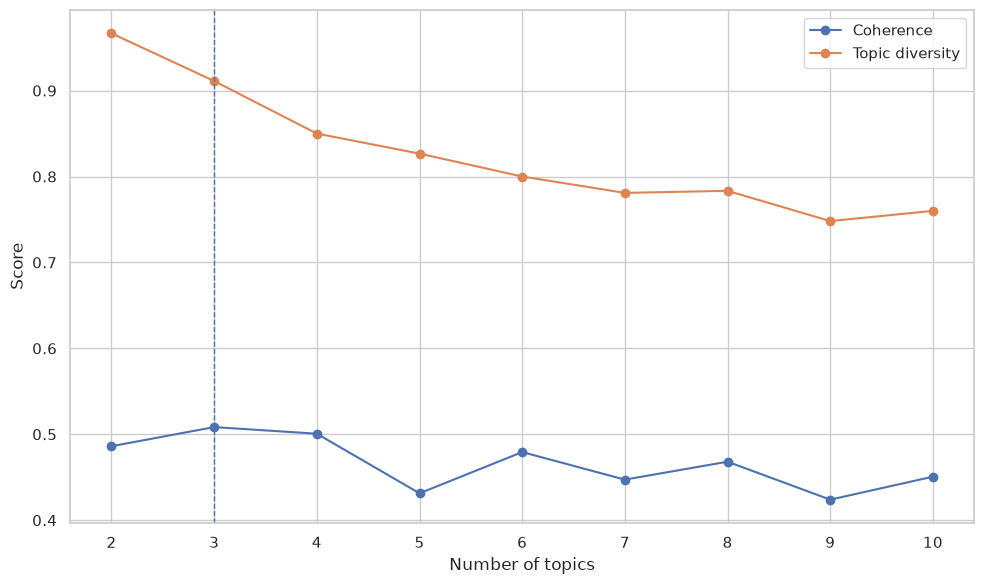

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/policy/img/lda_country_coherence_diversity_australia.png


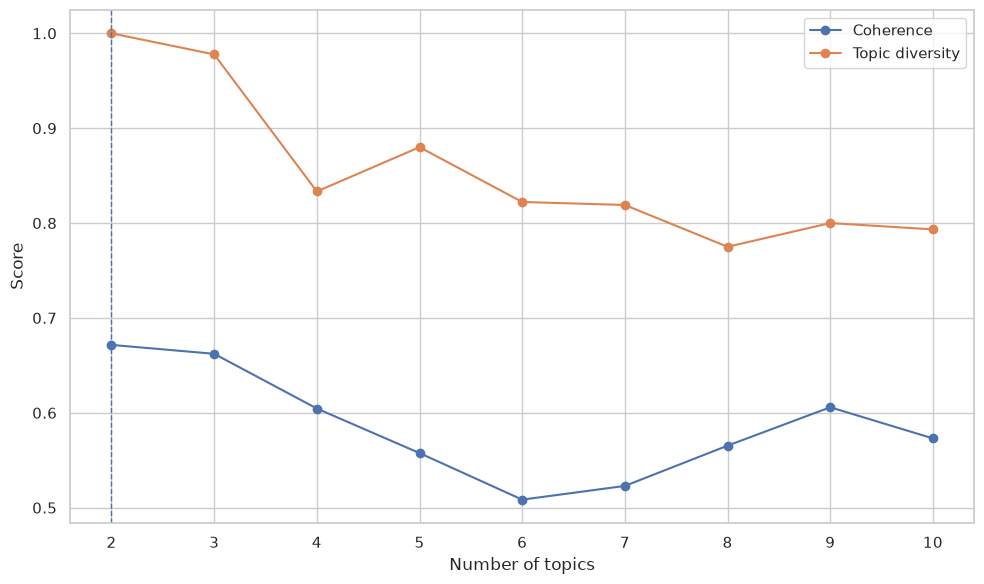

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/policy/img/lda_country_coherence_diversity_france.png


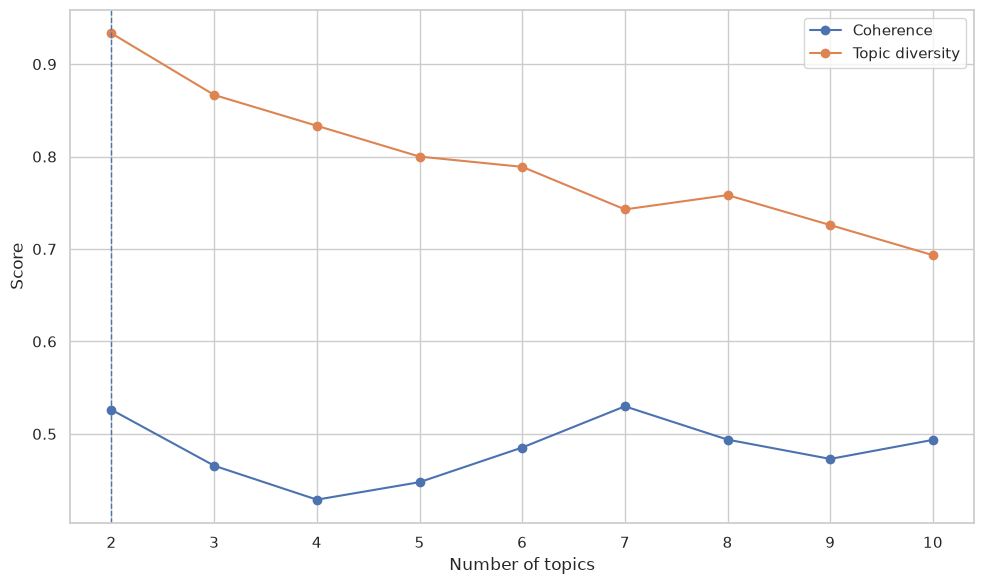

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/policy/img/lda_country_coherence_diversity_ireland.png


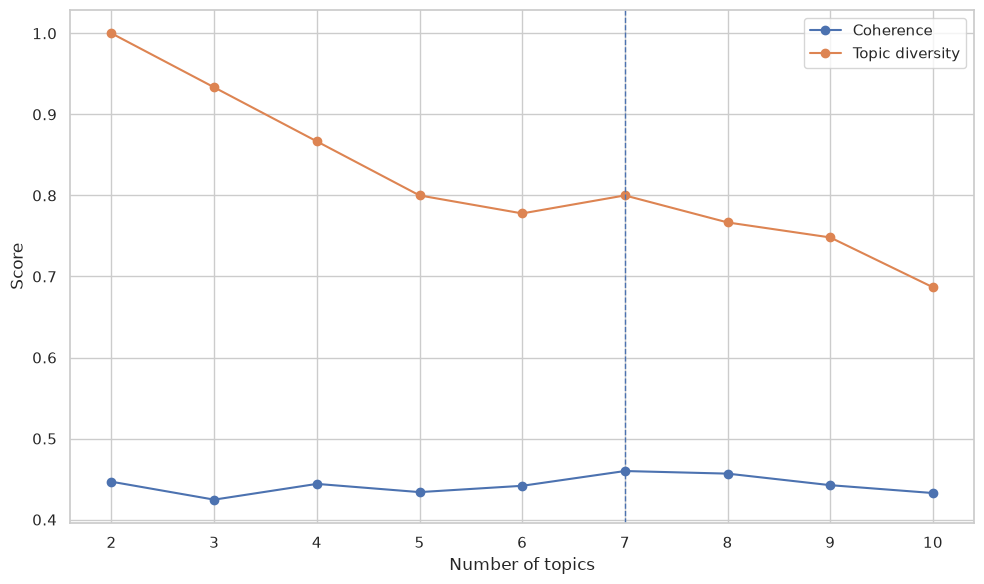

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/policy/img/lda_country_coherence_diversity_usa.png
Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/policy/output/lda_country_coherence_diversity.csv


In [14]:
# ==========================================
# Step 12: Plot coherence and diversity by country
# ==========================================

country_score_rows = []

for country, result in country_results.items():
    country_scores_df = pd.DataFrame({
        "country": country,
        "num_topics": result["topic_range"],
        "coherence_score": result["coherence_scores"],
        "topic_diversity": result["diversity_scores"]
    })

    country_score_rows.append(country_scores_df)

    plt.figure(figsize=(10, 6))

    plt.plot(
        country_scores_df["num_topics"],
        country_scores_df["coherence_score"],
        marker="o",
        label="Coherence"
    )

    plt.plot(
        country_scores_df["num_topics"],
        country_scores_df["topic_diversity"],
        marker="o",
        label="Topic diversity"
    )

    plt.axvline(
        result["best_num_topics"],
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Number of topics")
    plt.ylabel("Score")
    # plt.title(f"LDA coherence and diversity: {country}")
    plt.legend()
    plt.tight_layout()

    safe_country = str(country).replace(" ", "_").lower()
    save_path = IMG_DIR / f"lda_country_coherence_diversity_{safe_country}.png"

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {save_path}")

country_scores_all_df = pd.concat(
    country_score_rows,
    ignore_index=True
)

country_scores_csv_path = OUT_DIR / "lda_country_coherence_diversity.csv"

country_scores_all_df.to_csv(
    country_scores_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved: {country_scores_csv_path}")

In [15]:
# ==========================================
# Step 13: Display best topics by country
# ==========================================

country_topic_rows = []
num_words = 15

for country, result in country_results.items():
    best_model_country = result["best_model"]
    best_num_topics_country = result["best_num_topics"]
    best_coherence_country = result["best_coherence"]
    best_diversity_country = result["best_diversity"]

    print("\n" + "=" * 100)
    print(f"Country: {country}")
    print(f"Documents: {result['document_count']}")
    print(f"Dictionary size: {result['dictionary_size']}")
    print(f"Adaptive no_below: {result['no_below_value']}")
    print(f"Best number of topics: {best_num_topics_country}")
    print(f"Best coherence score: {best_coherence_country:.4f}")
    print(f"Best topic diversity: {best_diversity_country:.4f}")

    for topic_id, terms in best_model_country.show_topics(
        num_topics=best_num_topics_country,
        num_words=num_words,
        formatted=False
    ):
        topic_terms = [
            term
            for term, weight in terms
        ]

        topic_weight_pairs = [
            f"{term} ({weight:.4f})"
            for term, weight in terms
        ]

        country_topic_rows.append({
            "country": country,
            "document_count": result["document_count"],
            "dictionary_size": result["dictionary_size"],
            "no_below_value": result["no_below_value"],
            "best_num_topics": best_num_topics_country,
            "best_coherence": best_coherence_country,
            "best_diversity": best_diversity_country,
            "topic_id": topic_id,
            "topic_terms": ", ".join(topic_terms),
            "topic_terms_with_weights": ", ".join(topic_weight_pairs)
        })

        print("\n" + "-" * 80)
        print(f"Topic {topic_id}")
        print(", ".join(topic_weight_pairs))

country_topics_df = pd.DataFrame(country_topic_rows)

country_topics_csv_path = OUT_DIR / "lda_best_topics_by_country.csv"

country_topics_df.to_csv(
    country_topics_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"\nSaved: {country_topics_csv_path}")


Country: australia
Documents: 319
Dictionary size: 1600
Adaptive no_below: 3
Best number of topics: 3
Best coherence score: 0.5083
Best topic diversity: 0.9111

--------------------------------------------------------------------------------
Topic 0
cognitive (0.0151), task (0.0121), respondent (0.0113), learner (0.0087), knowledge (0.0087), help (0.0076), critical (0.0075), offload (0.0067), skill (0.0064), load (0.0061), generate (0.0058), metacognitive (0.0055), principle (0.0054), research (0.0051), thinking (0.0047)

--------------------------------------------------------------------------------
Topic 1
principle (0.0184), privacy (0.0143), staff (0.0140), assessment (0.0116), guideline (0.0112), ethical (0.0090), responsible (0.0085), framework (0.0082), review (0.0078), academic (0.0077), integrity (0.0071), guidance (0.0063), security (0.0062), user (0.0061), personal (0.0056)

--------------------------------------------------------------------------------
Topic 2
submission